# Função Ortogonal Empírica (FOE)
No post anterior, vimos como calcular diferentes formas de Matrizes de Covariância Empírica (MCE): com defasagem temporal, com defasagem espacial e entre diferentes bases de dados. Também exploramos maneiras de visualizar essas informações por meio de mapas de calor, facilitando a interpretação dos padrões de variação presentes nos dados.

Agora, neste post, vamos avançar um passo além: exploraremos como aplicar a Função Ortogonal Empírica (FOE) sobre a MCE, como forma de extrair estruturas dominantes e padrões relevantes contidos nela.

## Primeira Intuição
Para entender por que aplicamos a FOE à MCE, é útil lembrar que uma matriz, ao ser multiplicada por um vetor, atua como uma transformação sobre os dados representados por esse vetor.

Nesse contexto, a MCE pode ser vista como uma matriz que descreve uma transformação linear específica — relacionada às covariâncias entre variáveis. A ideia da FOE é decompor essa transformação em "componentes principais" ordenadas, de forma que cada uma represente uma direção que explica a maior quantidade possível de variância dos dados.

Ou seja, ao aplicar a FOE sobre a MCE, estamos identificando os padrões mais relevantes (dominantes) de variação presentes nos dados. Essa decomposição será ilustrada com exemplos abaixo, o que tornará a intuição ainda mais clara.

Retomamos os dados trabalhados no post anterior, quando calculamos uma matriz de covariância empírica sem lag temporal nem espacial. Vamos utilizar essa matriz como exemplo. Abaixo retomamos o código utilizado para gerar os dados e calcular a matriz de covariância. Apenas alteramos a quantidade de dados, para tornar o exemplo mais intuitivo vizualmente.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

T = 3  # Número de anos
N = 3 # Número de regiões

TEMPORAL_LAG = 0 # Atraso temporal para a matriz de covariância

rng = np.random.default_rng(38)
coords = [(rng.normal(0, 1), rng.normal(0, 1)) for _ in range(N)]

# Gerando dados aleatórios para a matriz de dados
Z = rng.integers(0, 10, size=(T, N))

def covariance_func(Z, temporal_lag):
    T, _ = Z.shape
    Zc = (Z - Z.mean(axis=0))
    if temporal_lag == 0:
        return (Zc.T @ Zc) / T
    return (Zc[temporal_lag:].T @ Zc[:-temporal_lag]) / (T - temporal_lag)

C = covariance_func(Z, TEMPORAL_LAG)

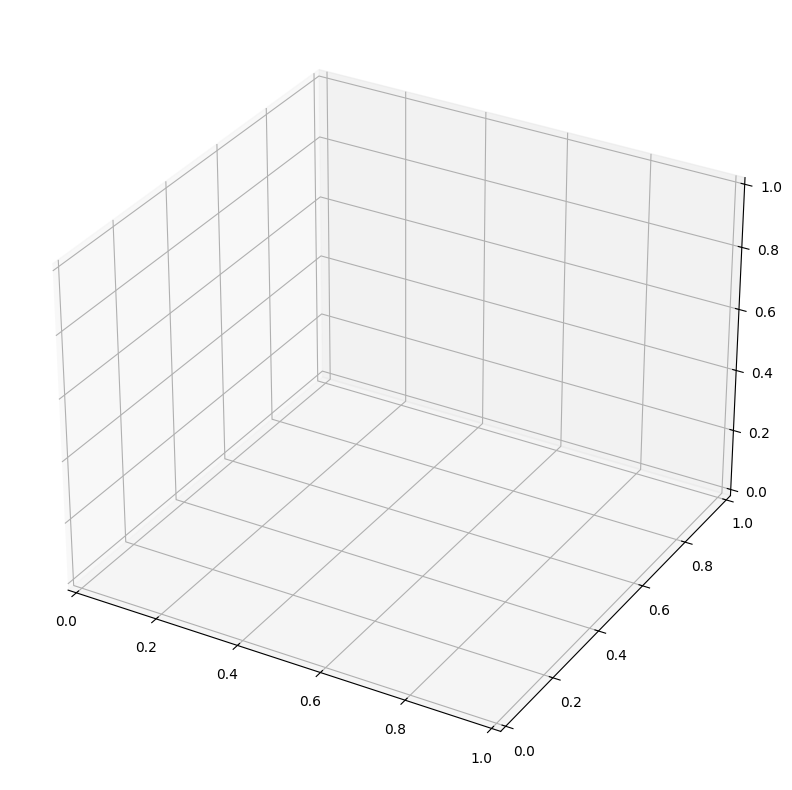

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Definir o plano original através de dois vetores base
u1 = np.array([1, 0, 0.5])  # Primeiro vetor do plano
u2 = np.array([0, 1, 0.3])  # Segundo vetor do plano


# Transformar os vetores base do plano
u1_transf = C @ u1
u2_transf = C @ u2

# Criar grade de pontos para representar o plano
def create_plane_points(v1, v2, size=2, resolution=10):
    """Cria uma grade de pontos para representar um plano"""
    s = np.linspace(-size, size, resolution)
    t = np.linspace(-size, size, resolution)
    S, T = np.meshgrid(s, t)
    
    # Cada ponto do plano = origem + s*v1 + t*v2
    points = np.zeros((resolution, resolution, 3))
    for i in range(resolution):
        for j in range(resolution):
            points[i, j] = S[i, j] * v1 + T[i, j] * v2
    
    return points, S, T

# Configuração da figura
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

def set_axes_equal(ax, vectors):
    all_points = np.array([[0, 0, 0]] + [vec for vec in vectors])
    mins = all_points.min(axis=0) - 4
    maxs = all_points.max(axis=0) + 4
    ranges = maxs - mins
    max_range = ranges.max()
    mid = (maxs + mins) / 2
    for axis, m, r in zip([ax.set_xlim, ax.set_ylim, ax.set_zlim], mid, [max_range]*3):
        axis(m - r/2, m + r/2)

# Parâmetros da animação
frames = 120
pause_frames = 10
resolution = 15  # Resolução da grade do plano (aumentada para superfície mais suave)

def animate(frame):
    # Limpar elementos anteriores
    ax.clear()
    
    # Calcular progresso da animação
    if frame < pause_frames:
        t = 0
        title = 'Plano original'
        color = 'blue'
        alpha = 0.45
    elif frame < frames - pause_frames:
        t = (frame - pause_frames) / (frames - 2 * pause_frames)
        t = np.clip(t, 0, 1)
        # Suavizar transição
        t = 3 * t**2 - 2 * t**3
        title = f'Transformação do plano (t={t:.2f})'
        # Interpolar cor de azul para vermelho
        color = (t, 0.1, 1-t, 1.0)  # RGBA format
        alpha = 0.45  # Mais opaco para melhor visualização
    else:
        t = 1
        title = 'Plano transformado'
        color = 'red'
        alpha = 0.45
    
    # Interpolar os vetores base do plano
    current_u1 = (1 - t) * u1 + t * u1_transf
    current_u2 = (1 - t) * u2 + t * u2_transf
    
    # Criar pontos do plano atual
    current_plane, S, T = create_plane_points(current_u1, current_u2, size=1.5, resolution=resolution)
    
    # Reconfigurar eixos
    all_vectors = [u1, u2, u1_transf, u2_transf]
    set_axes_equal(ax, all_vectors)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.grid(True)
    
    # Origem
    ax.scatter(0, 0, 0, color='black', s=100)
    
    # Definir cor para vetores (compatível com todos os elementos)
    if isinstance(color, tuple) and len(color) == 4:
        vector_color = color[:3]  # Use apenas RGB para quiver
    else:
        vector_color = color
    
    # Desenhar o plano como superfície sólida
    X = current_plane[:, :, 0]
    Y = current_plane[:, :, 1]
    Z = current_plane[:, :, 2]
    
    # Superfície sólida com transparência
    ax.plot_surface(X, Y, Z, color=color, alpha=alpha, shade=True, 
                   linewidth=0, antialiased=True)
    
    # Contorno do plano para melhor definição
    ax.contour(X, Y, Z, levels=10, colors=[vector_color], 
               alpha=alpha+0.3, linewidths=0.5)
    
    # Desenhar os vetores base do plano        
    ax.quiver(0, 0, 0, current_u1[0], current_u1[1], current_u1[2], 
              color=vector_color, arrow_length_ratio=0.1, linewidth=3, alpha=0.8)
    ax.quiver(0, 0, 0, current_u2[0], current_u2[1], current_u2[2], 
              color=vector_color, arrow_length_ratio=0.1, linewidth=3, alpha=0.8)
    
    # Marcar as pontas dos vetores base
    ax.scatter(*current_u1, color=vector_color, s=80, alpha=0.9)
    ax.scatter(*current_u2, color=vector_color, s=80, alpha=0.9)
    
    # Desenhar o vetor normal ao plano (produto vetorial)
    # Calcular o vetor normal ao plano
    normal = np.cross(current_u1, current_u2)
    normal_length = np.linalg.norm(normal)
    # Escalar o tamanho do vetor normal proporcional ao tamanho do plano (área do paralelogramo)
    scale = 1.3 + 0.1 * normal_length  # aumenta mais conforme o plano cresce
    if normal_length > 1e-8:
        normal_normalized = normal / normal_length * scale
    else:
        normal_normalized = normal

    # Cor destacada: laranja forte
    normal_color = (1.0, 0.4, 0.0)  # RGB laranja

    # Desenhar o vetor normal ao plano (produto vetorial)
    ax.quiver(0, 0, 0, normal_normalized[0], normal_normalized[1], normal_normalized[2], 
              color=normal_color, arrow_length_ratio=0.3, linewidth=4, alpha=0.8)

    # Adicionar vetores de referência suteis
    if t > 0:
        ax.quiver(0, 0, 0, u1[0], u1[1], u1[2], color='blue', alpha=0.2, 
                 arrow_length_ratio=0.05, linewidth=1)
        ax.quiver(0, 0, 0, u2[0], u2[1], u2[2], color='blue', alpha=0.2, 
                 arrow_length_ratio=0.05, linewidth=1)
    if t < 1:
        ax.quiver(0, 0, 0, u1_transf[0], u1_transf[1], u1_transf[2], color='red', alpha=0.2, 
                 arrow_length_ratio=0.05, linewidth=1)
        ax.quiver(0, 0, 0, u2_transf[0], u2_transf[1], u2_transf[2], color='red', alpha=0.2, 
                 arrow_length_ratio=0.05, linewidth=1)
    
    ax.set_title(title, fontsize=14, pad=20)
    
    # Informações no canto
    info_text = f'Vetores base originais:\n'
    info_text += f'u₁ = [{u1[0]:.1f}, {u1[1]:.1f}, {u1[2]:.1f}]\n'
    info_text += f'u₂ = [{u2[0]:.1f}, {u2[1]:.1f}, {u2[2]:.1f}]\n\n'
    info_text += f'Vetores base transformados:\n'
    info_text += f'C·u₁ = [{u1_transf[0]:.1f}, {u1_transf[1]:.1f}, {u1_transf[2]:.1f}]\n'
    info_text += f'C·u₂ = [{u2_transf[0]:.1f}, {u2_transf[1]:.1f}, {u2_transf[2]:.1f}]\n\n'
    info_text += f'Atual:\n'
    info_text += f'u₁ = [{current_u1[0]:.1f}, {current_u1[1]:.1f}, {current_u1[2]:.1f}]\n'
    info_text += f'u₂ = [{current_u2[0]:.1f}, {current_u2[1]:.1f}, {current_u2[2]:.1f}]'
    
    ax.text2D(0.02, 0.98, info_text, transform=ax.transAxes, fontsize=9, 
              verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    # Adicionar legenda
    legend_text = 'Azul: Vetores base\nRoxo: Vetor normal'
    ax.text2D(0.02, 0.02, legend_text, transform=ax.transAxes, fontsize=9,
              bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Criar animação
anim = FuncAnimation(fig, animate, frames=frames, interval=100, repeat=True)

plt.tight_layout()
plt.show()

# Para salvar como GIF 
anim.save('transformacao_plano.gif', writer='pillow', fps=10)

Autovalores:
[-1.77635684e-15  8.20917286e+00  1.57908271e+01]

Autovetores (colunas):
[[ 0.37186787 -0.84277029 -0.38916902]
 [-0.77754191 -0.05377223 -0.62652783]
 [-0.50709255 -0.53558079  0.67528539]]

Direção principal (autovetor com maior autovalor): [-0.38916902 -0.62652783  0.67528539]
Intensidade da variância nessa direção: 15.790827135384882


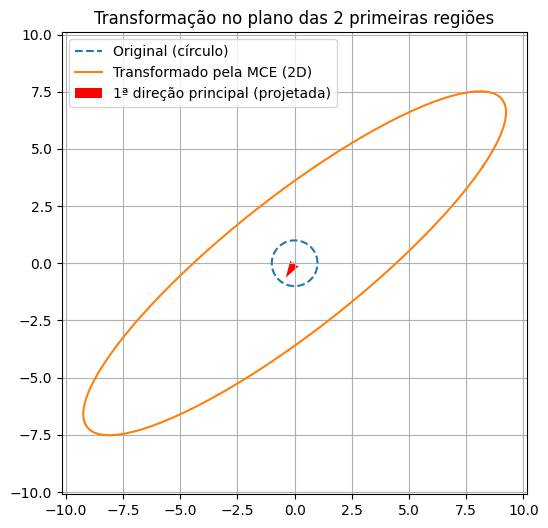

In [4]:
# Passo 1: Autovalores e autovetores
autovalores, autovetores = np.linalg.eig(C)

# Passo 2: Identificar o autovalor máximo e o autovetor correspondente
indice_maior = np.argmax(autovalores)
direcao_principal = autovetores[:, indice_maior]
intensidade = autovalores[indice_maior]

print("Autovalores:")
print(autovalores)
print("\nAutovetores (colunas):")
print(autovetores)

print(f"\nDireção principal (autovetor com maior autovalor): {direcao_principal}")
print(f"Intensidade da variância nessa direção: {intensidade}")

# Passo 3: Visualização geométrica (opcional, mas ajuda na intuição)
import matplotlib.pyplot as plt

# Gerar um círculo no plano 2D (x e y apenas)
theta = np.linspace(0, 2 * np.pi, 100)
circle_2d = np.array([np.cos(theta), np.sin(theta)])

# Transformar esse círculo com a submatriz 2x2 da MCE (regiões 0 e 1)
C_2d = C[:2, :2]
transformed_2d = C_2d @ circle_2d

# Também projetar o autovetor principal para 2D (mesmas duas regiões)
direcao_principal_2d = direcao_principal[:2]

# Plot
plt.figure(figsize=(6, 6))
plt.plot(circle_2d[0], circle_2d[1], label='Original (círculo)', linestyle='--')
plt.plot(transformed_2d[0], transformed_2d[1], label='Transformado pela MCE (2D)')
plt.quiver(0, 0, *direcao_principal_2d, angles='xy', scale_units='xy', scale=1, color='red', label='1ª direção principal (projetada)')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.title("Transformação no plano das 2 primeiras regiões")
plt.show()



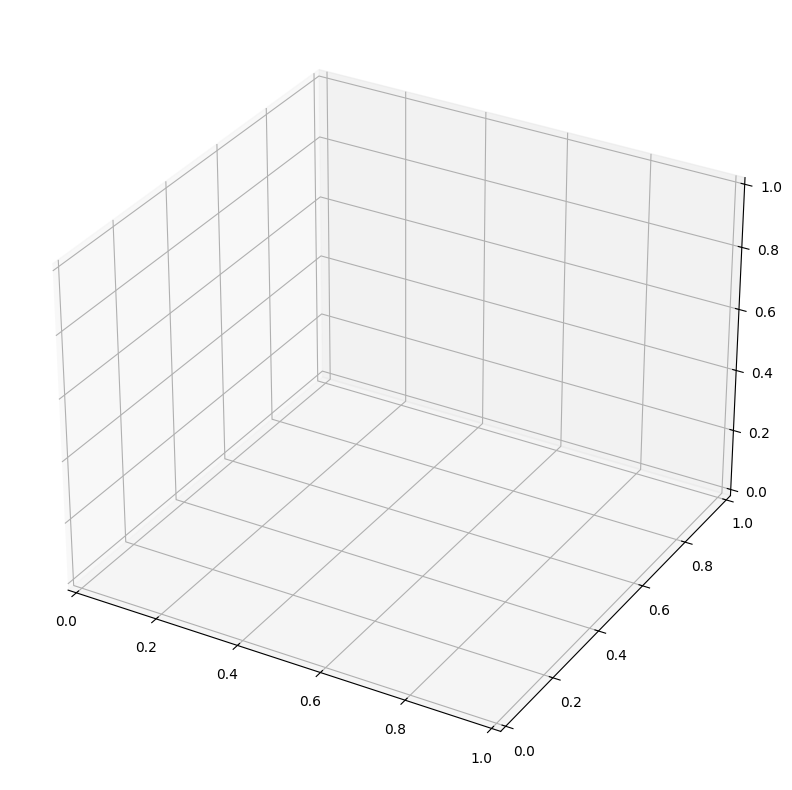

In [5]:
# Definir o plano original através de dois vetores base
u1 = np.array([1, 0, 0.5])  # Primeiro vetor do plano
u2 = np.array([0, 1, 0.3])  # Segundo vetor do plano


# Transformar os vetores base do plano usando o maior autovalor e autovetor
# autovetores[:, indice_maior] já é um vetor unitário, autovalores[indice_maior] é o maior autovalor
u1_transf = autovalores[indice_maior] * (np.dot(u1, autovetores[:, indice_maior]) * autovetores[:, indice_maior])
u2_transf = autovalores[indice_maior] * (np.dot(u2, autovetores[:, indice_maior]) * autovetores[:, indice_maior])

# Criar grade de pontos para representar o plano
def create_plane_points(v1, v2, size=2, resolution=10):
    """Cria uma grade de pontos para representar um plano"""
    s = np.linspace(-size, size, resolution)
    t = np.linspace(-size, size, resolution)
    S, T = np.meshgrid(s, t)
    
    # Cada ponto do plano = origem + s*v1 + t*v2
    points = np.zeros((resolution, resolution, 3))
    for i in range(resolution):
        for j in range(resolution):
            points[i, j] = S[i, j] * v1 + T[i, j] * v2
    
    return points, S, T

# Configuração da figura
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

def set_axes_equal(ax, vectors):
    all_points = np.array([[0, 0, 0]] + [vec for vec in vectors])
    mins = all_points.min(axis=0) - 4
    maxs = all_points.max(axis=0) + 4
    ranges = maxs - mins
    max_range = ranges.max()
    mid = (maxs + mins) / 2
    for axis, m, r in zip([ax.set_xlim, ax.set_ylim, ax.set_zlim], mid, [max_range]*3):
        axis(m - r/2, m + r/2)

# Parâmetros da animação
frames = 120
pause_frames = 10
resolution = 15  # Resolução da grade do plano (aumentada para superfície mais suave)

def animate(frame):
    # Limpar elementos anteriores
    ax.clear()
    
    # Calcular progresso da animação
    if frame < pause_frames:
        t = 0
        title = 'Plano original'
        color = 'blue'
        alpha = 0.45
    elif frame < frames - pause_frames:
        t = (frame - pause_frames) / (frames - 2 * pause_frames)
        t = np.clip(t, 0, 1)
        # Suavizar transição
        t = 3 * t**2 - 2 * t**3
        title = f'Transformação do plano (t={t:.2f})'
        # Interpolar cor de azul para vermelho
        color = (t, 0.1, 1-t, 1.0)  # RGBA format
        alpha = 0.45  # Mais opaco para melhor visualização
    else:
        t = 1
        title = 'Plano transformado'
        color = 'red'
        alpha = 0.45
    
    # Interpolar os vetores base do plano
    current_u1 = (1 - t) * u1 + t * u1_transf
    current_u2 = (1 - t) * u2 + t * u2_transf
    
    # Criar pontos do plano atual
    current_plane, S, T = create_plane_points(current_u1, current_u2, size=1.5, resolution=resolution)
    
    # Reconfigurar eixos
    all_vectors = [u1, u2, u1_transf, u2_transf]
    set_axes_equal(ax, all_vectors)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.grid(True)
    
    # Origem
    ax.scatter(0, 0, 0, color='black', s=100)
    
    # Definir cor para vetores (compatível com todos os elementos)
    if isinstance(color, tuple) and len(color) == 4:
        vector_color = color[:3]  # Use apenas RGB para quiver
    else:
        vector_color = color
    
    # Desenhar o plano como superfície sólida
    X = current_plane[:, :, 0]
    Y = current_plane[:, :, 1]
    Z = current_plane[:, :, 2]
    
    # Superfície sólida com transparência
    ax.plot_surface(X, Y, Z, color=color, alpha=alpha, shade=True, 
                   linewidth=0, antialiased=True)
    
    # Contorno do plano para melhor definição
    ax.contour(X, Y, Z, levels=10, colors=[vector_color], 
               alpha=alpha+0.3, linewidths=0.5)
    
    # Desenhar os vetores base do plano        
    ax.quiver(0, 0, 0, current_u1[0], current_u1[1], current_u1[2], 
              color=vector_color, arrow_length_ratio=0.1, linewidth=3, alpha=0.8)
    ax.quiver(0, 0, 0, current_u2[0], current_u2[1], current_u2[2], 
              color=vector_color, arrow_length_ratio=0.1, linewidth=3, alpha=0.8)
    
    # Marcar as pontas dos vetores base
    ax.scatter(*current_u1, color=vector_color, s=80, alpha=0.9)
    ax.scatter(*current_u2, color=vector_color, s=80, alpha=0.9)
    
    # Desenhar o vetor normal ao plano (produto vetorial)
    # Calcular o vetor normal ao plano
    normal = np.cross(current_u1, current_u2)
    normal_length = np.linalg.norm(normal)
    # Escalar o tamanho do vetor normal proporcional ao tamanho do plano (área do paralelogramo)
    scale = 1.3 + 0.1 * normal_length  # aumenta mais conforme o plano cresce
    if normal_length > 1e-8:
        normal_normalized = normal / normal_length * scale
    else:
        normal_normalized = normal

    # Cor destacada: laranja forte
    normal_color = (1.0, 0.4, 0.0)  # RGB laranja

    # Desenhar o vetor normal ao plano (produto vetorial)
    ax.quiver(0, 0, 0, normal_normalized[0], normal_normalized[1], normal_normalized[2], 
              color=normal_color, arrow_length_ratio=0.3, linewidth=4, alpha=0.8)

    # Adicionar vetores de referência suteis
    if t > 0:
        ax.quiver(0, 0, 0, u1[0], u1[1], u1[2], color='blue', alpha=0.2, 
                 arrow_length_ratio=0.05, linewidth=1)
        ax.quiver(0, 0, 0, u2[0], u2[1], u2[2], color='blue', alpha=0.2, 
                 arrow_length_ratio=0.05, linewidth=1)
    if t < 1:
        ax.quiver(0, 0, 0, u1_transf[0], u1_transf[1], u1_transf[2], color='red', alpha=0.2, 
                 arrow_length_ratio=0.05, linewidth=1)
        ax.quiver(0, 0, 0, u2_transf[0], u2_transf[1], u2_transf[2], color='red', alpha=0.2, 
                 arrow_length_ratio=0.05, linewidth=1)
    
    ax.set_title(title, fontsize=14, pad=20)
    
    # Informações no canto
    info_text = f'Vetores base originais:\n'
    info_text += f'u₁ = [{u1[0]:.1f}, {u1[1]:.1f}, {u1[2]:.1f}]\n'
    info_text += f'u₂ = [{u2[0]:.1f}, {u2[1]:.1f}, {u2[2]:.1f}]\n\n'
    info_text += f'Vetores base transformados:\n'
    info_text += f'C·u₁ = [{u1_transf[0]:.1f}, {u1_transf[1]:.1f}, {u1_transf[2]:.1f}]\n'
    info_text += f'C·u₂ = [{u2_transf[0]:.1f}, {u2_transf[1]:.1f}, {u2_transf[2]:.1f}]\n\n'
    info_text += f'Atual:\n'
    info_text += f'u₁ = [{current_u1[0]:.1f}, {current_u1[1]:.1f}, {current_u1[2]:.1f}]\n'
    info_text += f'u₂ = [{current_u2[0]:.1f}, {current_u2[1]:.1f}, {current_u2[2]:.1f}]'
    
    ax.text2D(0.02, 0.98, info_text, transform=ax.transAxes, fontsize=9, 
              verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    # Adicionar legenda
    legend_text = 'Azul: Vetores base\nRoxo: Vetor normal'
    ax.text2D(0.02, 0.02, legend_text, transform=ax.transAxes, fontsize=9,
              bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Criar animação
anim = FuncAnimation(fig, animate, frames=frames, interval=100, repeat=True)

plt.tight_layout()
plt.show()

# Para salvar como GIF 
anim.save('transformacao_plano.gif', writer='pillow', fps=10)